In [1]:
import pandas as pd
import xgboost as xgb
from sklearn.metrics import recall_score
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import log_loss, roc_auc_score, roc_curve
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import confusion_matrix, classification_report, precision_score, recall_score, accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import precision_score, confusion_matrix
from sklearn.ensemble import ExtraTreesClassifier
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv('data.csv', sep=';')

df.columns = df.columns.str.strip()  # Strip column names FIRST
df = df[df["Target"].isin(["Dropout", "Graduate"])]  # Then filter
df= df.drop(columns=['Application mode', 'Application order'])
df["Target"] = df["Target"].map({"Dropout": 1, "Graduate": 0})  # Then map

In [2]:
X1 = df.drop("Target", axis=1)
y1 = df["Target"]

In [3]:
model = ExtraTreesClassifier(n_estimators=300)
model.fit(X1, y1)

importances = model.feature_importances_
feature_names = X1.columns

top_idx = np.argsort(importances)[-15:]
top_features = feature_names[top_idx]
top_importances = importances[top_idx]

top10_df = pd.DataFrame({
    "Feature": top_features,
    "Importance": top_importances
}).sort_values("Importance", ascending=False)

print("Top 10 Features Based on ExtraTrees:")
print(top10_df)


Top 10 Features Based on ExtraTrees:
                                   Feature  Importance
14     Curricular units 2nd sem (approved)    0.146993
13        Curricular units 2nd sem (grade)    0.135144
12                 Tuition fees up to date    0.093387
11        Curricular units 1st sem (grade)    0.082966
10     Curricular units 1st sem (approved)    0.079489
9                       Scholarship holder    0.040339
8   Curricular units 2nd sem (evaluations)    0.029588
7                                   Debtor    0.028788
6                        Age at enrollment    0.027090
5                                   Course    0.026681
4   Curricular units 1st sem (evaluations)    0.026242
3                                   Gender    0.022947
2                          Admission grade    0.021924
1           Previous qualification (grade)    0.020501
0      Curricular units 2nd sem (enrolled)    0.020279


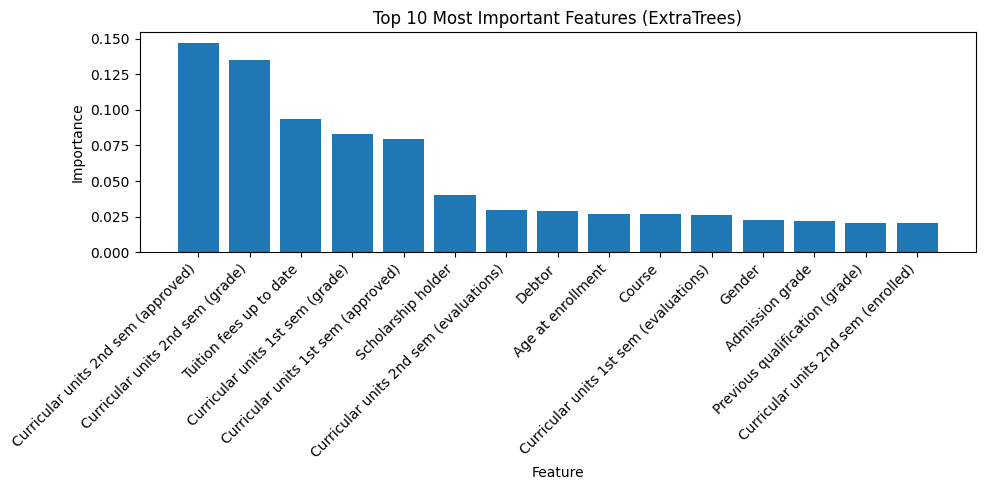

In [4]:
plt.figure(figsize=(10, 5))
plt.bar(top10_df["Feature"], top10_df["Importance"])
plt.xticks(rotation=45, ha="right")
plt.title("Top 10 Most Important Features (ExtraTrees)")
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()

In [5]:

# Random Forest model
rf = RandomForestClassifier(n_estimators=300)
rf.fit(X1, y1)

RandomForestClassifier(n_estimators=300)


TOP 20 FEATURES (RandomForest):

                                   Feature  Importance
14     Curricular units 2nd sem (approved)    0.220619
13     Curricular units 1st sem (approved)    0.127315
12        Curricular units 2nd sem (grade)    0.118181
11        Curricular units 1st sem (grade)    0.075844
10                 Tuition fees up to date    0.052935
9   Curricular units 2nd sem (evaluations)    0.035248
8                        Age at enrollment    0.032178
7                          Admission grade    0.030426
6                                   Course    0.026878
5           Previous qualification (grade)    0.026327
4   Curricular units 1st sem (evaluations)    0.025890
3                       Scholarship holder    0.020514
2      Curricular units 2nd sem (enrolled)    0.019697
1      Curricular units 1st sem (enrolled)    0.019171
0                      Father's occupation    0.017647


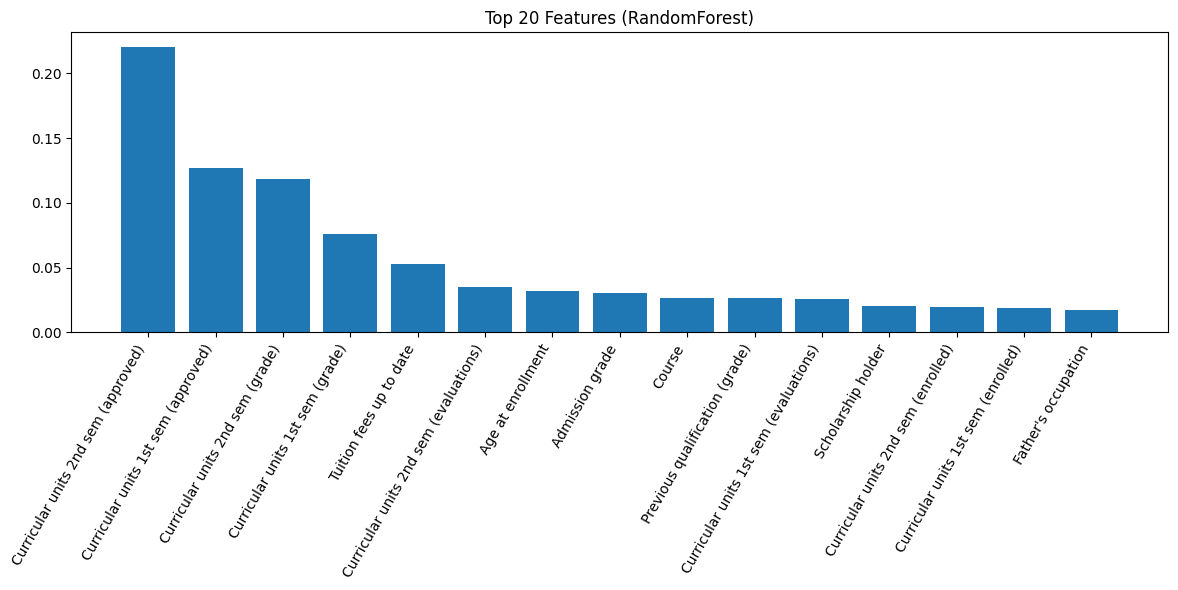

In [6]:
# Feature importances
importances = rf.feature_importances_
feature_names = X1.columns

# Get top 20 features
top_idx = np.argsort(importances)[-15:]
top_features = feature_names[top_idx]
top_importances = importances[top_idx]

rf_top20 = pd.DataFrame({
    "Feature": top_features,
    "Importance": top_importances
}).sort_values("Importance", ascending=False)

print("\nTOP 20 FEATURES (RandomForest):\n")
print(rf_top20)

# Plot
plt.figure(figsize=(12,6))
plt.bar(rf_top20["Feature"], rf_top20["Importance"])
plt.xticks(rotation=60, ha="right")
plt.title("Top 20 Features (RandomForest)")
plt.tight_layout()
plt.show()


TOP 20 FEATURES (XGBoost):

                                           Feature  Importance
14             Curricular units 2nd sem (approved)    0.327409
13                         Tuition fees up to date    0.112177
12             Curricular units 1st sem (enrolled)    0.071393
11             Curricular units 2nd sem (enrolled)    0.032385
10  Curricular units 1st sem (without evaluations)    0.030412
9              Curricular units 1st sem (approved)    0.028022
8              Curricular units 2nd sem (credited)    0.027155
7   Curricular units 2nd sem (without evaluations)    0.025166
6                                           Debtor    0.024705
5                               Scholarship holder    0.022789
4                                           Course    0.019377
3           Curricular units 1st sem (evaluations)    0.018810
2           Curricular units 2nd sem (evaluations)    0.018675
1                                      Nacionality    0.016684
0                         

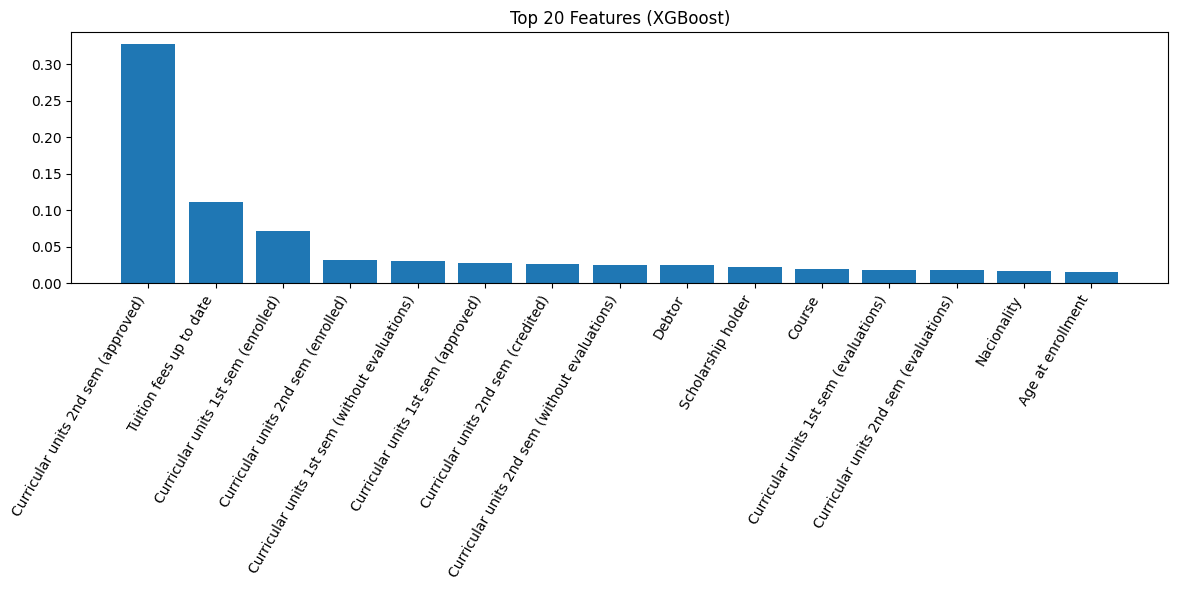

In [7]:

# XGBoost model
xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    eval_metric="logloss"
)

xgb.fit(X1, y1)

# Feature importances
importances = xgb.feature_importances_
feature_names = X1.columns

# Get top 20 features
top_idx = np.argsort(importances)[-15:]
top_features = feature_names[top_idx]
top_importances = importances[top_idx]

xgb_top20 = pd.DataFrame({
    "Feature": top_features,
    "Importance": top_importances
}).sort_values("Importance", ascending=False)

print("\nTOP 20 FEATURES (XGBoost):\n")
print(xgb_top20)

# Plot
plt.figure(figsize=(12,6))
plt.bar(xgb_top20["Feature"], xgb_top20["Importance"])
plt.xticks(rotation=60, ha="right")
plt.title("Top 20 Features (XGBoost)")
plt.tight_layout()
plt.show()

In [8]:
selected_features = [
    'Curricular units 2nd sem (approved)',
    'Curricular units 1st sem (approved)',
    'Tuition fees up to date',
    'Curricular units 2nd sem (grade)',
    'Curricular units 1st sem (grade)',
    'Curricular units 2nd sem (enrolled)',
    'Curricular units 1st sem (enrolled)',
    'Curricular units 2nd sem (evaluations)',
    'Curricular units 1st sem (evaluations)',
    'Debtor',
    'Course',
    'Scholarship holder',
    'Curricular units 1st sem (without evaluations)',
    'Curricular units 2nd sem (without evaluations)',
    'Age at enrollment'
]


In [9]:
X = df[selected_features]
y = df['Target']

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [11]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

In [12]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_res)
X_test_scaled = scaler.transform(X_test)

In [13]:


knn = KNeighborsClassifier()

param_grid = {
    'n_neighbors': list(range(1, 21)),  # 1 to 20 neighbors
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

In [14]:
grid = GridSearchCV(knn, param_grid, cv=5, scoring='accuracy', return_train_score=True)
grid.fit(X_train_scaled, y_train_res)
print("Best KNN params:", grid.best_params_)
best_knn = grid.best_estimator_

Best KNN params: {'metric': 'manhattan', 'n_neighbors': 20, 'weights': 'distance'}


In [15]:
results = pd.DataFrame(grid.cv_results_)

In [16]:
best_knn.fit(X_train_scaled, y_train_res)

# -----------------------------
# 5. Predictions
# -----------------------------
y_train_pred = best_knn.predict(X_train_scaled)
y_test_pred = best_knn.predict(X_test_scaled)

# -----------------------------
# 6. Metrics: Accuracy, Precision, Recall
# -----------------------------
print("Train Accuracy:", accuracy_score(y_train_res, y_train_pred))
print("Test Accuracy:", accuracy_score(y_test, y_test_pred))

print("\nTrain Precision & Recall:")
print("Precision:", precision_score(y_train_res, y_train_pred, average='weighted'))
print("Recall:", recall_score(y_train_res, y_train_pred, average='weighted'))

print("\nTest Precision & Recall:")
print("Precision:", precision_score(y_test, y_test_pred, average='weighted'))
print("Recall:", recall_score(y_test, y_test_pred, average='weighted'))

# -----------------------------
# 7. Confusion Matrices
# -----------------------------
print("\nTrain Confusion Matrix:")
print(confusion_matrix(y_train_res, y_train_pred))


Train Accuracy: 0.9855687606112055
Test Accuracy: 0.9159779614325069

Train Precision & Recall:
Precision: 0.9857593436084616
Recall: 0.9855687606112055

Test Precision & Recall:
Precision: 0.9170069653204034
Recall: 0.9159779614325069

Train Confusion Matrix:
[[1759    8]
 [  43 1724]]


KNN Train Log Loss: 0.019982598591374832
KNN Test Log Loss: 0.4391101348102848
KNN Train AUC: 0.9996707543728336
KNN Test AUC: 0.9643107513861449


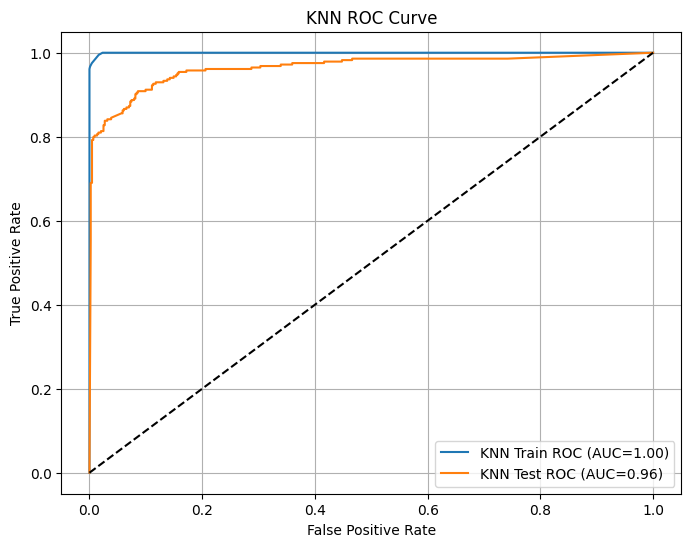

In [17]:
# Log Loss (directly)
print("KNN Train Log Loss:", log_loss(y_train_res, best_knn.predict_proba(X_train_scaled)))
print("KNN Test Log Loss:", log_loss(y_test, best_knn.predict_proba(X_test_scaled)))

# AUC (directly)
print("KNN Train AUC:", roc_auc_score(y_train_res, best_knn.predict_proba(X_train_scaled)[:,1]))
print("KNN Test AUC:", roc_auc_score(y_test, best_knn.predict_proba(X_test_scaled)[:,1]))

# ROC Curve
plt.figure(figsize=(8,6))
fpr_train, tpr_train, _ = roc_curve(y_train_res, best_knn.predict_proba(X_train_scaled)[:,1])
fpr_test, tpr_test, _ = roc_curve(y_test, best_knn.predict_proba(X_test_scaled)[:,1])
plt.plot(fpr_train, tpr_train, label=f'KNN Train ROC (AUC={roc_auc_score(y_train_res, best_knn.predict_proba(X_train_scaled)[:,1]):.2f})')
plt.plot(fpr_test, tpr_test, label=f'KNN Test ROC (AUC={roc_auc_score(y_test, best_knn.predict_proba(X_test_scaled)[:,1]):.2f})')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("KNN ROC Curve")
plt.legend()
plt.grid(True)
plt.show()


In [18]:
lr = LogisticRegression(max_iter=1000)
param_grid_lr = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l2'],  # l1 requires solver='liblinear'
    'solver': ['lbfgs']
}

grid_lr = GridSearchCV(lr, param_grid_lr, cv=5, scoring='accuracy')
grid_lr.fit(X_train_scaled, y_train_res)

best_lr = grid_lr.best_estimator_
y_train_pred_lr = best_lr.predict(X_train_scaled)
y_test_pred_lr = best_lr.predict(X_test_scaled)

print("=== Logistic Regression ===")
print("Best Params:", grid_lr.best_params_)
print("Train Accuracy:", accuracy_score(y_train_res, y_train_pred_lr))
print("Test Accuracy:", accuracy_score(y_test, y_test_pred_lr))
print("Train Precision:", precision_score(y_train_res, y_train_pred_lr, average='weighted'))
print("Train Recall:", recall_score(y_train_res, y_train_pred_lr, average='weighted'))
print("Test Precision:", precision_score(y_test, y_test_pred_lr, average='weighted'))
print("Test Recall:", recall_score(y_test, y_test_pred_lr, average='weighted'))
print("Train Confusion Matrix:\n", confusion_matrix(y_train_res, y_train_pred_lr))
print("Test Confusion Matrix:\n", confusion_matrix(y_test, y_test_pred_lr))

=== Logistic Regression ===
Best Params: {'C': 1, 'penalty': 'l2', 'solver': 'lbfgs'}
Train Accuracy: 0.9003961516694963
Test Accuracy: 0.9214876033057852
Train Precision: 0.9020696988029112
Train Recall: 0.9003961516694963
Test Precision: 0.9232640509596113
Test Recall: 0.9214876033057852
Train Confusion Matrix:
 [[1648  119]
 [ 233 1534]]
Test Confusion Matrix:
 [[405  37]
 [ 20 264]]


LogReg Train Log Loss: 0.2535874361519945
LogReg Test Log Loss: 0.21667478122615838
LogReg Train AUC: 0.9518310124399119
LogReg Test AUC: 0.9686125804601364


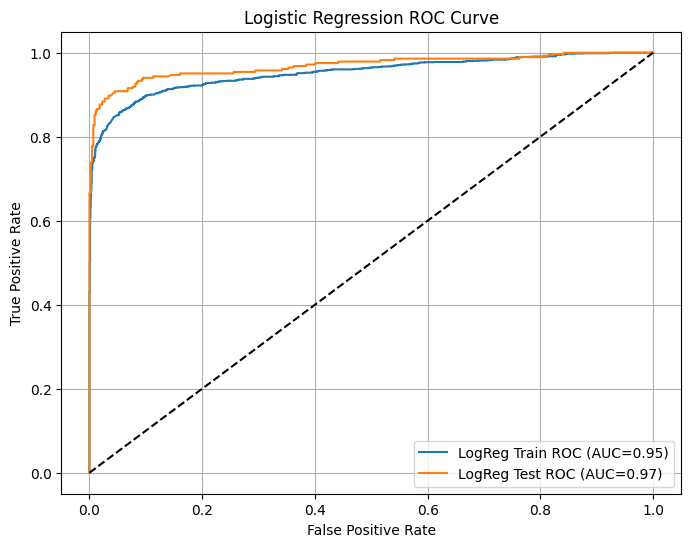

In [19]:
# Log Loss (directly)
print("LogReg Train Log Loss:", log_loss(y_train_res, best_lr.predict_proba(X_train_scaled)))
print("LogReg Test Log Loss:", log_loss(y_test, best_lr.predict_proba(X_test_scaled)))

# AUC (directly)
print("LogReg Train AUC:", roc_auc_score(y_train_res, best_lr.predict_proba(X_train_scaled)[:,1]))
print("LogReg Test AUC:", roc_auc_score(y_test, best_lr.predict_proba(X_test_scaled)[:,1]))

# ROC Curve
plt.figure(figsize=(8,6))
fpr_train, tpr_train, _ = roc_curve(y_train_res, best_lr.predict_proba(X_train_scaled)[:,1])
fpr_test, tpr_test, _ = roc_curve(y_test, best_lr.predict_proba(X_test_scaled)[:,1])
plt.plot(fpr_train, tpr_train, label=f'LogReg Train ROC (AUC={roc_auc_score(y_train_res, best_lr.predict_proba(X_train_scaled)[:,1]):.2f})')
plt.plot(fpr_test, tpr_test, label=f'LogReg Test ROC (AUC={roc_auc_score(y_test, best_lr.predict_proba(X_test_scaled)[:,1]):.2f})')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Logistic Regression ROC Curve")
plt.legend()
plt.grid(True)
plt.show()


In [20]:
svm = SVC(random_state=42)
param_grid_svm = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto']
}

grid_svm = GridSearchCV(svm, param_grid_svm, cv=5, scoring='accuracy')
grid_svm.fit(X_train_scaled, y_train_res)

best_svm = grid_svm.best_estimator_
y_train_pred_svm = best_svm.predict(X_train_scaled)
y_test_pred_svm = best_svm.predict(X_test_scaled)

print("\n=== SVM ===")
print("Best Params:", grid_svm.best_params_)
print("Train Accuracy:", accuracy_score(y_train_res, y_train_pred_svm))
print("Test Accuracy:", accuracy_score(y_test, y_test_pred_svm))
print("Train Precision:", precision_score(y_train_res, y_train_pred_svm, average='weighted'))
print("Train Recall:", recall_score(y_train_res, y_train_pred_svm, average='weighted'))
print("Test Precision:", precision_score(y_test, y_test_pred_svm, average='weighted'))
print("Test Recall:", recall_score(y_test, y_test_pred_svm, average='weighted'))
print("Train Confusion Matrix:\n", confusion_matrix(y_train_res, y_train_pred_svm))
print("Test Confusion Matrix:\n", confusion_matrix(y_test, y_test_pred_svm))


=== SVM ===
Best Params: {'C': 10, 'gamma': 'auto', 'kernel': 'rbf'}
Train Accuracy: 0.9224674589700057
Test Accuracy: 0.9159779614325069
Train Precision: 0.9249110839590985
Train Recall: 0.9224674589700057
Test Precision: 0.9158486526117815
Test Recall: 0.9159779614325069
Train Confusion Matrix:
 [[1697   70]
 [ 204 1563]]
Test Confusion Matrix:
 [[413  29]
 [ 32 252]]


SVM Train Log Loss: 0.21687972231795227
SVM Test Log Loss: 0.22226476533416237
SVM Train AUC: 0.9661509552767217
SVM Test AUC: 0.9643426167866929


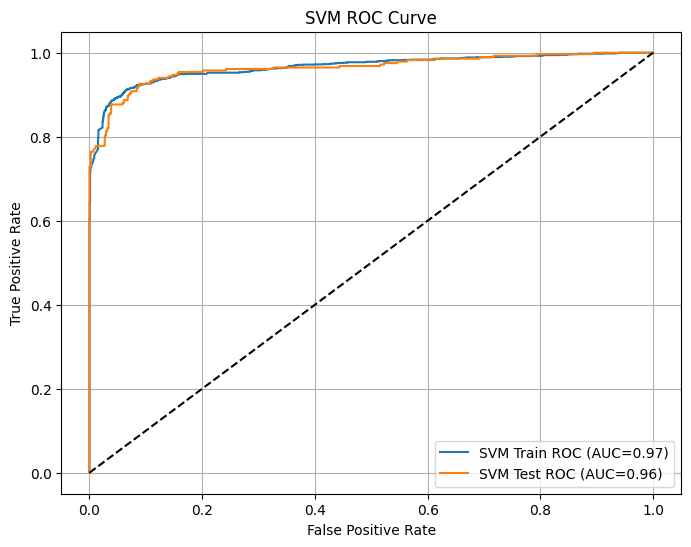

In [21]:
# Ensure probability=True
best_svm.probability = True
best_svm.fit(X_train_scaled, y_train_res)

# Log Loss (directly)
print("SVM Train Log Loss:", log_loss(y_train_res, best_svm.predict_proba(X_train_scaled)))
print("SVM Test Log Loss:", log_loss(y_test, best_svm.predict_proba(X_test_scaled)))

# AUC (directly)
print("SVM Train AUC:", roc_auc_score(y_train_res, best_svm.predict_proba(X_train_scaled)[:,1]))
print("SVM Test AUC:", roc_auc_score(y_test, best_svm.predict_proba(X_test_scaled)[:,1]))

# ROC Curve
plt.figure(figsize=(8,6))
fpr_train, tpr_train, _ = roc_curve(y_train_res, best_svm.predict_proba(X_train_scaled)[:,1])
fpr_test, tpr_test, _ = roc_curve(y_test, best_svm.predict_proba(X_test_scaled)[:,1])
plt.plot(fpr_train, tpr_train, label=f'SVM Train ROC (AUC={roc_auc_score(y_train_res, best_svm.predict_proba(X_train_scaled)[:,1]):.2f})')
plt.plot(fpr_test, tpr_test, label=f'SVM Test ROC (AUC={roc_auc_score(y_test, best_svm.predict_proba(X_test_scaled)[:,1]):.2f})')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("SVM ROC Curve")
plt.legend()
plt.grid(True)
plt.show()


In [22]:
rf = RandomForestClassifier()
param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'bootstrap': [True, False]
}

grid_rf = GridSearchCV(rf, param_grid_rf, cv=5, scoring='accuracy')
grid_rf.fit(X_train_scaled, y_train_res)

best_rf = grid_rf.best_estimator_
y_train_pred_rf = best_rf.predict(X_train_scaled)
y_test_pred_rf = best_rf.predict(X_test_scaled)

print("\n=== Random Forest ===")
print("Best Params:", grid_rf.best_params_)
print("Train Accuracy:", accuracy_score(y_train_res, y_train_pred_rf))
print("Test Accuracy:", accuracy_score(y_test, y_test_pred_rf))
print("Train Precision:", precision_score(y_train_res, y_train_pred_rf, average='weighted'))
print("Train Recall:", recall_score(y_train_res, y_train_pred_rf, average='weighted'))
print("Test Precision:", precision_score(y_test, y_test_pred_rf, average='weighted'))
print("Test Recall:", recall_score(y_test, y_test_pred_rf, average='weighted'))
print("Train Confusion Matrix:\n", confusion_matrix(y_train_res, y_train_pred_rf))
print("Test Confusion Matrix:\n", confusion_matrix(y_test, y_test_pred_rf))




=== Random Forest ===
Best Params: {'bootstrap': False, 'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Train Accuracy: 0.989247311827957
Test Accuracy: 0.9269972451790633
Train Precision: 0.989247311827957
Train Recall: 0.989247311827957
Test Precision: 0.9271650690113332
Test Recall: 0.9269972451790633
Train Confusion Matrix:
 [[1748   19]
 [  19 1748]]
Test Confusion Matrix:
 [[414  28]
 [ 25 259]]


Train Log Loss: 0.02570850931726454
Test Log Loss: 0.2961725094433447
Train AUC: 0.9996352035317679
Test AUC: 0.9694410808743865


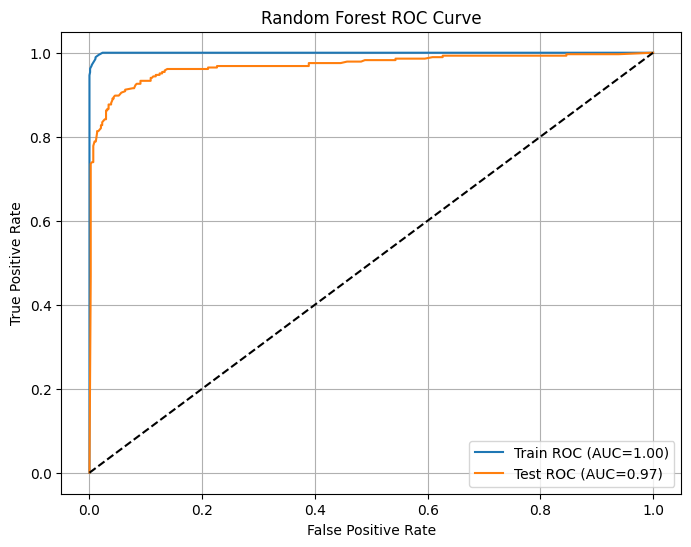

In [23]:


# Log Loss (directly)
print("Train Log Loss:", log_loss(y_train_res, best_rf.predict_proba(X_train_scaled)))
print("Test Log Loss:", log_loss(y_test, best_rf.predict_proba(X_test_scaled)))

# AUC (directly)
print("Train AUC:", roc_auc_score(y_train_res, best_rf.predict_proba(X_train_scaled)[:,1]))
print("Test AUC:", roc_auc_score(y_test, best_rf.predict_proba(X_test_scaled)[:,1]))

# ROC Curve
plt.figure(figsize=(8,6))
fpr_train, tpr_train, _ = roc_curve(y_train_res, best_rf.predict_proba(X_train_scaled)[:,1])
fpr_test, tpr_test, _ = roc_curve(y_test, best_rf.predict_proba(X_test_scaled)[:,1])
plt.plot(fpr_train, tpr_train, label=f'Train ROC (AUC={roc_auc_score(y_train_res, best_rf.predict_proba(X_train_scaled)[:,1]):.2f})')
plt.plot(fpr_test, tpr_test, label=f'Test ROC (AUC={roc_auc_score(y_test, best_rf.predict_proba(X_test_scaled)[:,1]):.2f})')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Random Forest ROC Curve")
plt.legend()
plt.grid(True)
plt.show()

Fitting 5 folds for each of 192 candidates, totalling 960 fits


C:\Users\sai bharath\AppData\Local\Programs\Python\Python310\lib\site-packages\xgboost\sklearn.py:885: UserWarning: `early_stopping_rounds` in `fit` method is deprecated for better compatibility with scikit-learn, use `early_stopping_rounds` in constructor or`set_params` instead.
  warnings.warn(


Best Params: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200, 'reg_alpha': 1, 'reg_lambda': 1, 'subsample': 1.0}
Train Log Loss: 0.1580156987889876
Test Log Loss: 0.19845929668136605
Train AUC: 0.9865273522085879
Test AUC: 0.9725877891785101


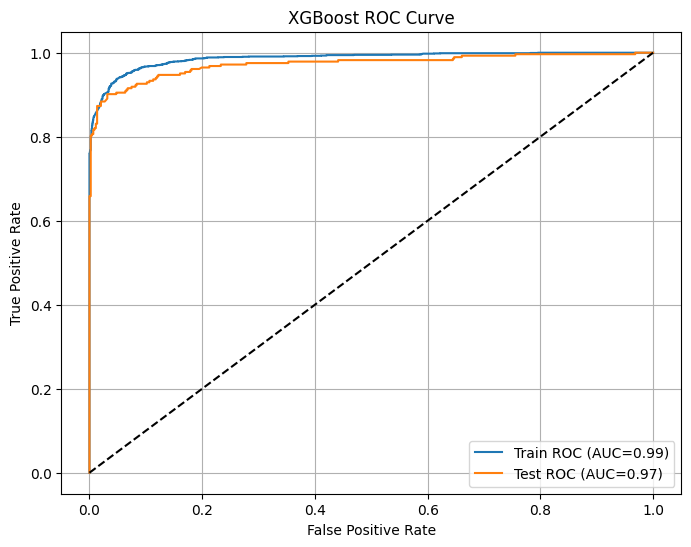

In [24]:

param_grid = {
    'n_estimators': [100, 150, 200],
    'max_depth': [3, 5],           # reduced depth
    'learning_rate': [0.05, 0.1],  # smaller learning rate
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
    'reg_alpha': [0, 1],           # L1 regularization
    'reg_lambda': [1, 5]           # L2 regularization
}

import xgboost as xgb

# Correct: create the model once
xgb_clf = xgb.XGBClassifier(
    max_depth=5,
    n_estimators=150,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=1,
    reg_lambda=1,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

# Fit the model
xgb_clf.fit(X_train_scaled, y_train_res)

# Use the fitted model for predictions and evaluation
y_pred = xgb_clf.predict(X_test_scaled)
y_proba = xgb_clf.predict_proba(X_test_scaled)


skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_xgb = GridSearchCV(
    estimator=xgb_clf,
    param_grid=param_grid,
    scoring='recall',       # focus on recall
    cv=skf,
    n_jobs=-1,
    verbose=1
)


grid_xgb.fit(
    X_train_scaled, y_train_res,
    eval_set=[(X_test_scaled, y_test)],
    early_stopping_rounds=20,
    verbose=False
)

best_xgb = grid_xgb.best_estimator_
print("Best Params:", grid_xgb.best_params_)

# ------------------ Direct Evaluation ------------------
print("Train Log Loss:", log_loss(y_train_res, best_xgb.predict_proba(X_train_scaled)))
print("Test Log Loss:", log_loss(y_test, best_xgb.predict_proba(X_test_scaled)))

print("Train AUC:", roc_auc_score(y_train_res, best_xgb.predict_proba(X_train_scaled)[:,1]))
print("Test AUC:", roc_auc_score(y_test, best_xgb.predict_proba(X_test_scaled)[:,1]))

# ROC Curve
plt.figure(figsize=(8,6))
fpr_train, tpr_train, _ = roc_curve(y_train_res, best_xgb.predict_proba(X_train_scaled)[:,1])
fpr_test, tpr_test, _ = roc_curve(y_test, best_xgb.predict_proba(X_test_scaled)[:,1])
plt.plot(fpr_train, tpr_train, label=f'Train ROC (AUC={roc_auc_score(y_train_res, best_xgb.predict_proba(X_train_scaled)[:,1]):.2f})')
plt.plot(fpr_test, tpr_test, label=f'Test ROC (AUC={roc_auc_score(y_test, best_xgb.predict_proba(X_test_scaled)[:,1]):.2f})')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("XGBoost ROC Curve")
plt.legend()
plt.grid(True)
plt.show()

In [25]:
y_train_pred = best_xgb.predict(X_train_scaled)
y_test_pred = best_xgb.predict(X_test_scaled)

print("Train Recall:", recall_score(y_train_res, y_train_pred))
print("Test Recall:", recall_score(y_test, y_test_pred))




print("Train Precision:", precision_score(y_train_res, y_train_pred))
print("Test Precision:", precision_score(y_test, y_test_pred))

print("Train Confusion Matrix:\n", confusion_matrix(y_train_res, y_train_pred))
print("Test Confusion Matrix:\n", confusion_matrix(y_test, y_test_pred))



Train Recall: 0.9168081494057725
Test Recall: 0.9119718309859155
Train Precision: 0.9625668449197861
Test Precision: 0.8993055555555556
Train Confusion Matrix:
 [[1704   63]
 [ 147 1620]]
Test Confusion Matrix:
 [[413  29]
 [ 25 259]]


In [26]:
y_test_pred_thresh = (best_xgb.predict_proba(X_test_scaled)[:,1] >= 0.3).astype(int)
print("Test Recall with 0.3 threshold:", recall_score(y_test, y_test_pred_thresh))


Test Recall with 0.3 threshold: 0.9471830985915493


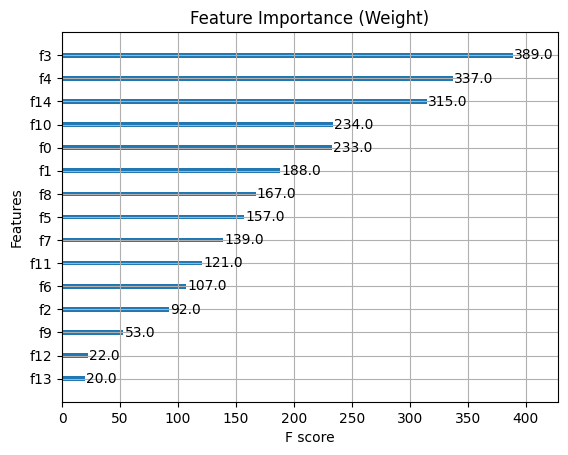

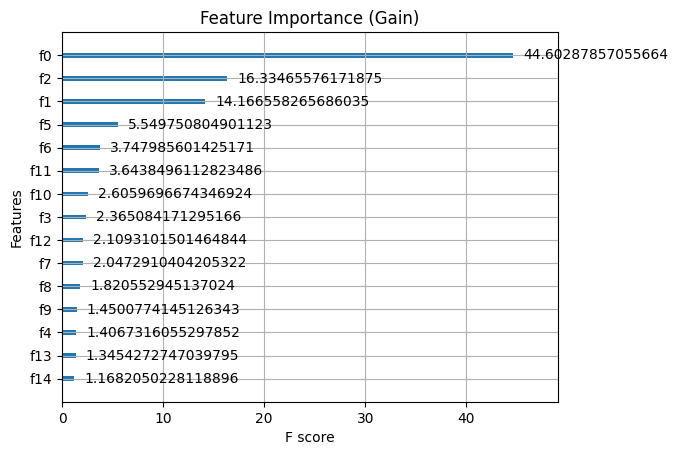

In [27]:
import matplotlib.pyplot as plt

# Plot feature importance
xgb.plot_importance(best_xgb, max_num_features=20, importance_type='weight')
plt.title("Feature Importance (Weight)")
plt.show()

# Other importance types:
# 'weight' → number of times a feature is used in trees
# 'gain' → average gain of splits using the feature (better)
# 'cover' → average coverage (samples affected) of splits
xgb.plot_importance(best_xgb, max_num_features=20, importance_type='gain')
plt.title("Feature Importance (Gain)")
plt.show()
